# Demonstartor Model 2
## Controlled Pendulum

In [128]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import minimize

**Parameters**

In [129]:
# Pendulum Parameters
g = 9.81 # m/s^2
L = 0.4  # m
m = 16   # kg

# Motor/drive parameters
k_M = 29e-3      # Nm/A (torque constant)
k_n = 12000/48   # RPM/V (speed constant)
U_M = 16.0       # V (supply)
L_M = 123e-6     # H
R_M = 135e-3     # Ohm
i_M = 60.0       # gear ratio
eta_M = 0.85     # gear efficiency

# Sensor/ADC parameters
U_0 = 3.0           # V
R_pot = 60e3        # Ohm (unused in this simple mapping)
R3 = 30e3           # Ohm (unused here)
R4 = 10e3           # Ohm (unused here)
alpha_max = 270 * np.pi / 180  # rad
U_ADC = 3.0         # V
n_bits_ADC = 6

**Reference:**

In [130]:
def reference_trajectory(t):
    """
    Reference trajectory for the pendulum.
    A simple cosine with a frequency of 1 Hz from q = -110° to q = -70°.
    """
    return -np.deg2rad(90) + np.deg2rad(20) * np.cos(t)

**Pendulum Dynamics**

In [131]:
def pendulum_dynamics(t, omega, q, torque):
    domega_dt = -(g / L) * np.cos(q) + torque / (m * L**2)
    dq_dt = omega
    return domega_dt, dq_dt

**Sensor Model**

In [132]:
def sensor(q, noise_std=0.0):
    """Map angle q to ADC voltage with optional noise & quantization."""
    is_scalar = np.isscalar(q)
    q = np.atleast_1d(q)

    alpha = q + np.pi/2
    U_a = U_0 * (3/4 - alpha / alpha_max)

    if noise_std and noise_std > 0:
        U_a = U_a + np.random.normal(0.0, noise_std, size=U_a.shape)

    # Clip to ADC range
    U_a = np.clip(U_a, 0.0, U_ADC)

    # Quantize
    levels = 2**n_bits_ADC
    delta = U_ADC / (levels - 1)
    U_a_quantized = np.round(U_a / delta) * delta

    return U_a_quantized[0] if is_scalar else U_a_quantized

**Motor**

In [133]:
def drive_dynamics(t, M, u_control, omega):
    """
    Very simple motor/drive model:
    U = U_M * u_control
    n = i_M * omega * 30 / pi  (convert rad/s at output to RPM at motor)
    I = M / (eta_M * i_M * k_M)
    dI/dt = (U - I*R_M - n/k_n)/L_M
    dM/dt = eta_M * i_M * k_M * dI/dt
    """
    U = U_M * u_control
    n_rpm = i_M * omega * 30.0 / np.pi
    I = M / (eta_M * i_M * k_M + 1e-12)  # avoid divide-by-zero
    dI = (U - I*R_M - n_rpm / k_n) / L_M
    dM = eta_M * i_M * k_M * dI
    return dM

**System Functions**

In [134]:
def system_equations(t, y, u_control):
    omega, q, M = y
    dω, dq = pendulum_dynamics(t, omega, q, M)
    dM = drive_dynamics(t, M, u_control, omega)
    return np.array([dω, dq, dM], dtype=float)

**PID Controller**

In [135]:
class PIDController:
    def __init__(self, Kp, Ki, Kd, T, u_min=-1.0, u_max=1.0):
        self.Kp = float(Kp)
        self.Ki = float(Ki)
        self.Kd = float(Kd)
        self.T  = float(T)
        self.u_min = u_min
        self.u_max = u_max
        self.e_prev = 0.0
        self.I = 0.0

    def compute_control(self, ref, meas):
        e = ref - meas
        # derivative (backward diff)
        d = (e - self.e_prev) / self.T
        # tentative control
        u = self.Kp * e + self.Kd * d + self.Ki * self.I
        # apply saturation
        u_sat = np.clip(u, self.u_min, self.u_max)
        # anti-windup: only integrate if not saturated or if error drives it back
        if (u == u_sat) or ((u > self.u_max) and (e < 0)) or ((u < self.u_min) and (e > 0)):
            self.I += e * self.T
        self.e_prev = e
        return float(u_sat)

**Simulation**

In [136]:
omega_0 = 0.0
q_0 = -np.deg2rad(70)   # start near -70°
M_0 = 0.0
initial_state = np.array([omega_0, q_0, M_0], dtype=float)

dt_control = 0.02     # controller step [s]
dt_sim     = 0.002    # output sampling within each control step [s]
t_end      = 10.0

t_control = np.arange(0.0, t_end + 1e-12, dt_control)
num_steps = len(t_control)

In [137]:
def simulate(params, sensor_noise=0.0, quantize=True):
    Kp, Ki, Kd = params
    controller = PIDController(Kp, Ki, Kd, dt_control)

    t_values = []
    omega_values = []
    q_values = []
    u_values = []
    ref_values = []

    y = initial_state.copy()

    for k in range(num_steps - 1):
        t0 = t_control[k]
        t1 = t_control[k+1]

        # reference and measurement (turn off noise for optimization)
        ref_angle = reference_trajectory(t0)
        if quantize:
            ref_meas = sensor(ref_angle, noise_std=0.0)
            q_meas = sensor(y[1], noise_std=sensor_noise)
            # track in "voltage space" (or just track angles directly)
            # We'll track angles directly for clarity:
            ref = ref_angle
            meas = y[1]
        else:
            ref = ref_angle
            meas = y[1]

        # control law
        u = controller.compute_control(ref, meas)

        # integrate plant with constant u over [t0, t1]
        t_eval = np.arange(t0, t1 + 1e-12, dt_sim)
        sol = solve_ivp(lambda t, x: system_equations(t, x, u),
                        [t0, t1], y, t_eval=t_eval, method='BDF', vectorized=False)

        # update state for next step
        y = sol.y[:, -1]

        # store
        t_values.extend(sol.t.tolist())
        omega_values.extend(sol.y[0, :].tolist())
        q_values.extend(sol.y[1, :].tolist())
        u_values.extend([u] * len(sol.t))
        ref_values.extend([ref] * len(sol.t))

    return (np.array(t_values), np.array(omega_values),
            np.array(q_values), np.array(u_values), np.array(ref_values))

In [138]:
def objective_function(params):
    # keep params inside bounds (sometimes optimizers explore edges)
    params = np.clip(params, [0,0,0], [500,500,500])
    t, omega, q, u, ref = simulate(params, sensor_noise=0.0, quantize=False)
    # mean squared tracking error on angle
    err = np.mean((q - ref)**2)
    # small penalty on control effort (optional)
    err += 1e-4 * np.mean(u**2)
    return float(err)

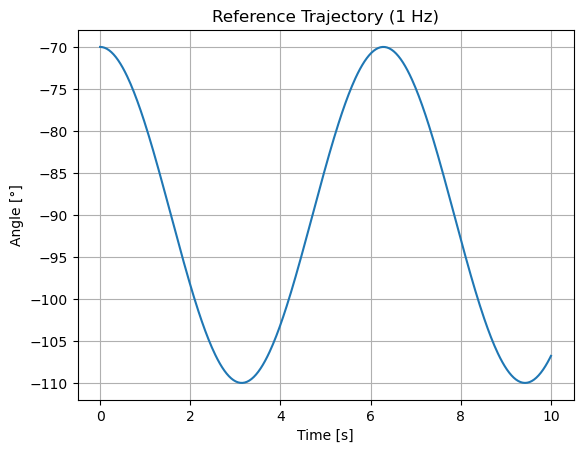

In [139]:
# -----------------------------
# Quick plot of the reference
# -----------------------------
t_ref = np.linspace(0, 10, 400)  # 2 seconds
reference = reference_trajectory(t_ref)
plt.figure()
plt.plot(t_ref, np.rad2deg(reference))
plt.xlabel("Time [s]")
plt.ylabel("Angle [°]")
plt.title("Reference Trajectory (1 Hz)")
plt.grid(True)
plt.show()

In [142]:
# Optimize PID
# -----------------------------
initial_params = np.array([10.0, 200.0, 5.0])
bounds = [(0, 500), (0, 500), (0, 500)]

result = minimize(objective_function, initial_params, bounds=bounds, method='L-BFGS-B',
                  options=dict(maxiter=50))
Kp_opt, Ki_opt, Kd_opt = result.x
print(f"Optimized PID parameters: Kp={Kp_opt:.3f}, Ki={Ki_opt:.3f}, Kd={Kd_opt:.3f}")

ValueError: Values in `t_eval` are not within `t_span`.

In [143]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import minimize

# --------------------
# Physical pendulum + motor
# --------------------
g = 9.81   # m/s^2
L = 0.4    # m
m = 16.0   # kg

# Motor/drive (same params you used)
k_M   = 29e-3     # Nm/A
k_n   = 12000/48  # RPM/V
U_M   = 16.0      # V  (supply)
L_M   = 123e-6    # H
R_M   = 135e-3    # Ohm
i_M   = 60.0      # gear ratio
eta_M = 0.85      # efficiency

def reference_trajectory(t):
    # Cosine sweep around -90°, amplitude 20°, 1 rad/s (not 1 Hz, but smooth)
    return -np.deg2rad(90) + np.deg2rad(20) * np.cos(t)

# ----- Sensor model (with optional quantization) -----
U_0 = 3.0      # V
alpha_max = 270 * np.pi / 180  # rad
U_ADC = 3.0    # V
n_bits_ADC = 6

def _angle_to_voltage(q):
    # alpha = q + pi/2 ; U = U0*(3/4 - alpha/alpha_max)
    alpha = q + np.pi/2
    return U_0 * (0.75 - alpha / alpha_max)

def _voltage_to_angle(U):
    # invert mapping, clip to feasible range
    U = np.clip(U, 0.0, U_ADC)
    alpha = alpha_max * (0.75 - U / U_0)
    return alpha - np.pi/2

def measure_angle(q_true, noise_std=0.0, quantize=True, rng=None):
    """Return an angle estimate produced by the ADC chain."""
    if rng is None:
        rng = np.random.default_rng()
    U = _angle_to_voltage(q_true)
    if noise_std > 0:
        U = U + rng.normal(0.0, noise_std)
    # clip to ADC range
    U = np.clip(U, 0.0, U_ADC)
    if quantize:
        levels = 2 ** n_bits_ADC
        delta = U_ADC / (levels - 1)
        U = np.round(U / delta) * delta
    # back to angle for controller
    return _voltage_to_angle(U)

# ----- Plant dynamics -----
def drive_dMdt(M, u_control, omega):
    """
    Simple electrical drive model integrated as a first-order system in torque M.
    u_control in [-1,1] -> motor voltage = U_M * u_control
    """
    U = U_M * u_control
    n_rpm = i_M * omega * 30.0 / np.pi     # mechanical speed at motor [rpm]
    I = M / (eta_M * i_M * k_M)
    dI_dt = (U - I * R_M - n_rpm / k_n) / L_M
    dM_dt = eta_M * i_M * k_M * dI_dt
    return dM_dt

def system_rhs(t, x, u_control):
    """
    x = [omega, q, M]
    pendulum: q'' = -(g/L) * sin(q) + M / (m L^2)
              omega = dq/dt
    drive:    dM/dt from electrical model
    """
    omega, q, M = x
    domega = -(g / L) * np.sin(q) + M / (m * L**2)
    dq     = omega
    dM     = drive_dMdt(M, u_control, omega)
    return np.array([domega, dq, dM], dtype=float)

# --------------------
# Discrete PID (T = controller sample time)
# --------------------
class PIDController:
    def __init__(self, Kp, Ki, Kd, T, umin=-1.0, umax=1.0):
        self.Kp, self.Ki, self.Kd = Kp, Ki, Kd
        self.T = T
        self.umin, self.umax = umin, umax
        self.e_km1 = 0.0
        self.e_km2 = 0.0
        self.u_km1 = 0.0

    def step(self, e_k):
        # Incremental (velocity) form to avoid integral windup accumulation
        a0 = (self.Kp + self.Kd / self.T)
        a1 = (self.Ki * self.T - 2 * self.Kd / self.T - self.Kp)
        a2 = (self.Kd / self.T)

        u_k = self.u_km1 + a0*e_k + a1*self.e_km1 + a2*self.e_km2

        # saturate + simple back-calculation anti-windup (clip only output)
        u_k = np.clip(u_k, self.umin, self.umax)

        self.u_km1, self.e_km2, self.e_km1 = u_k, self.e_km1, e_k
        return u_k

# --------------------
# Simulation with zero-order hold on control
# --------------------
omega_0 = 0.0
q_0     = -np.deg2rad(70.0)   # start near -70°
M_0     = 0.0
x0 = np.array([omega_0, q_0, M_0], dtype=float)

dt_control = 0.1
dt_sim     = 0.01
t_end      = 20.0

def simulate(params, sensor_noise=0.0, quantize=True, seed=1234):
    Kp, Ki, Kd = params
    pid = PIDController(Kp, Ki, Kd, T=dt_control)

    rng = np.random.default_rng(seed)

    t_vals   = []
    omega_ts = []
    q_ts     = []
    u_ts     = []
    r_ts     = []

    x = x0.copy()

    # number of control intervals
    n_steps = int(np.floor(t_end / dt_control + 1e-12))

    for k in range(n_steps):
        t0 = k * dt_control
        t1 = min(t0 + dt_control, t_end)

        # reference + measurement (controller uses angle domain)
        r  = reference_trajectory(t0)
        y  = measure_angle(x[1], noise_std=sensor_noise, quantize=quantize, rng=rng)
        e  = r - y
        u  = pid.step(e)  # in [-1,1]

        # integrate plant with constant u over [t0, t1]
        n_pts = int(round((t1 - t0) / dt_sim)) + 1
        t_eval = np.linspace(t0, t1, n_pts)
        sol = solve_ivp(lambda t, s: system_rhs(t, s, u),
                        (t0, t1), x, t_eval=t_eval, method='BDF', vectorized=False)

        # advance state
        x = sol.y[:, -1]

        # store
        t_vals.extend(sol.t.tolist())
        omega_ts.extend(sol.y[0, :].tolist())
        q_ts.extend(sol.y[1, :].tolist())
        u_ts.extend([u] * sol.t.size)
        r_ts.extend([r] * sol.t.size)

        if t1 >= t_end - 1e-12:
            break

    return (np.array(t_vals), np.array(omega_ts), np.array(q_ts),
            np.array(u_ts), np.array(r_ts))

# --------------------
# Objective for PID tuning
# --------------------
def objective_function(params):
    # keep within bounds to avoid wild finite-diff probes
    params = np.clip(params, [0, 0, 0], [500, 500, 500])
    t, omega, q, u, r = simulate(params, sensor_noise=0.0, quantize=False)
    # tracking error on angle
    return float(np.mean((q - r)**2))

# --------------------
# Optimize
# --------------------
initial_params = np.array([10.0, 200.0, 5.0])
bounds = [(0, 500), (0, 500), (0, 500)]

result = minimize(objective_function, initial_params, bounds=bounds,
                  method='L-BFGS-B', options=dict(maxiter=50))

Kp_opt, Ki_opt, Kd_opt = result.x
print(f"Optimized PID parameters: Kp={Kp_opt:.3f}, Ki={Ki_opt:.3f}, Kd={Kd_opt:.3f}")


Optimized PID parameters: Kp=10.000, Ki=200.000, Kd=5.000
